In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df_t= pd.read_excel("../data/raw/RDSon_vs_Tj.xlsx")
df_r = pd.read_excel("../data/raw/mosfet_parameters.xlsx")

In [2]:
df_r.head()

,Parameter,Symbol,Min,Typ,Max,Unit,Condition
0,Drain-Source Voltage,VDS,NaN,NaN,120.0,V,Maximum rating
1,Drain Current,ID,NaN,NaN,300.0,A,"VGS=10V, DC current, Tj=25°C"
2,Threshold Voltage,VGS(th),2.6,3.1,3.6,V,"VDS=VGS, ID=270µA, Tj=25°C"
3,On-State Resistance,RDS(on),NaN,1.5,1.8,mΩ,"VGS=10V, ID=100A, Tj=25°C"
4,Maximum Junction Temperature,"Tj,max",NaN,NaN,175.0,°C,Operating temperature


In [3]:
Rth_JC = df_r.loc[
    df_r["Symbol"] == "RθJC", "Max"
].iloc[0]

Rth_JC

0.42

In [4]:
Tj_max = df_r.loc[
    df_r["Symbol"] == "Tj,max", "Max"
].iloc[0]
Tj_max

175.0

In [5]:
I = 100       # Drain Current [A]
Tc = 25       # Case Temperature [°C]

In [6]:
Tj = Tc
Rds_mohm = np.interp(
    Tj,
    df_t["Tj (°C)"],
    df_t["RDS(on) (mΩ)"]
)

print(Rds_mohm)

1.49


In [7]:
Rds = Rds_mohm / 1000
P_loss = I**2 * Rds
delta_T = P_loss*Rth_JC
Tj_new = Tc + delta_T

In [8]:
print("Current Tj:", Tj, "°C")
print("RDS(on):", Rds_mohm, "mΩ")
print("Conduction Loss:", P_loss, "W")
print("New Tj:", Tj_new, "°C")

Current Tj: 25 °C
RDS(on): 1.49 mΩ
Conduction Loss: 14.9 W
New Tj: 31.258 °C


In [9]:
Tj = Tj_new

Rds_mohm = np.interp(
    Tj,
    df_t["Tj (°C)"],
    df_t["RDS(on) (mΩ)"]
)

Rds = Rds_mohm / 1000

P_loss = I**2 * Rds

delta_T = P_loss * Rth_JC

Tj_new = Tc + delta_T

In [10]:
print("Current Tj:", Tj, "°C")
print("RDS(on):", Rds_mohm, "mΩ")
print("Conduction Loss:", P_loss, "W")
print("New Tj:", Tj_new, "°C")

Current Tj: 31.258 °C
RDS(on): 1.5400639999999999 mΩ
Conduction Loss: 15.40064 W
New Tj: 31.4682688 °C


In [11]:
Tj = Tc
tolerance = 0.001
max = 100
for r in range(max):
    Rds_mohm = np.interp(
        Tj,
        df_t["Tj (°C)"],
        df_t["RDS(on) (mΩ)"]
    )

    Rds = Rds_mohm / 1000

    P_loss = I**2 * Rds

    delta_T = P_loss * Rth_JC

    Tj_new = Tc + delta_T

    print(r + 1, Tj, "→", Tj_new)
    
    if abs(Tj_new - Tj) < tolerance:
        break
    else:
        Tj = Tj_new

1 25 → 31.258
2 31.258 → 31.4682688
3 31.4682688 → 31.47533383168
4 31.47533383168 → 31.47557121674445


In [12]:
Tc = 50
Tj = Tc
tolerance = 0.001
max = 100
for r in range(max):
    Rds_mohm = np.interp(
        Tj,
        df_t["Tj (°C)"],
        df_t["RDS(on) (mΩ)"]
    )

    Rds = Rds_mohm / 1000

    P_loss = I**2 * Rds

    delta_T = P_loss * Rth_JC

    Tj_new = Tc + delta_T

    print(r + 1, Tj, "→", Tj_new)
    
    if abs(Tj_new - Tj) < tolerance:
        break
    else:
        Tj = Tj_new

1 50 → 57.098
2 57.098 → 57.36034208
3 57.36034208 → 57.3700382432768
4 57.3700382432768 → 57.37039661347151


In [13]:
Tc_l = [25,50,75,100,125,150]

result_Tj = []
result_Rds = []
result_Ploss = []
tolerance = 0.001
max_iter = 100

for Tc in Tc_l:
    Tj = Tc
    print(f"\n=== Tc = {Tc} °C ===")
    
    for r in range(max_iter):
        Rds_mohm = np.interp(
            Tj,
            df_t["Tj (°C)"],
            df_t["RDS(on) (mΩ)"]
        )

        Rds = Rds_mohm / 1000

        P_loss = I**2 * Rds

        delta_T = P_loss * Rth_JC

        Tj_new = Tc + delta_T

        
        print(f"{r+1}회: {Tj:.3f} °C → {Tj_new:.3f} °C")
        if abs(Tj_new - Tj) < tolerance:
            break
        else:
            Tj = Tj_new
    result_Tj.append(Tj_new)
    result_Rds.append(Rds_mohm)
    result_Ploss.append(P_loss)



=== Tc = 25 °C ===
1회: 25.000 °C → 31.258 °C
2회: 31.258 °C → 31.468 °C
3회: 31.468 °C → 31.475 °C
4회: 31.475 °C → 31.476 °C

=== Tc = 50 °C ===
1회: 50.000 °C → 57.098 °C
2회: 57.098 °C → 57.360 °C
3회: 57.360 °C → 57.370 °C
4회: 57.370 °C → 57.370 °C

=== Tc = 75 °C ===
1회: 75.000 °C → 83.022 °C
2회: 83.022 °C → 83.372 °C
3회: 83.372 °C → 83.388 °C
4회: 83.388 °C → 83.388 °C

=== Tc = 100 °C ===
1회: 100.000 °C → 109.114 °C
2회: 109.114 °C → 109.527 °C
3회: 109.527 °C → 109.546 °C
4회: 109.546 °C → 109.547 °C

=== Tc = 125 °C ===
1회: 125.000 °C → 135.248 °C
2회: 135.248 °C → 135.764 °C
3회: 135.764 °C → 135.791 °C
4회: 135.791 °C → 135.792 °C
5회: 135.792 °C → 135.792 °C

=== Tc = 150 °C ===
1회: 150.000 °C → 161.508 °C
2회: 161.508 °C → 162.165 °C
3회: 162.165 °C → 162.203 °C
4회: 162.203 °C → 162.205 °C
5회: 162.205 °C → 162.205 °C


In [14]:
df_result = pd.DataFrame({
    "Tc (°C)": Tc_l,
    "Tj (°C)": result_Tj,
    "Rds (mΩ)": result_Rds,
    "Ploss (W)": result_Ploss
})
df_result

,Tc (°C),Tj (°C),Rds (mΩ),Ploss (W)
0,25,31.475571,1.541803,15.418027
1,50,57.370397,1.754856,17.548563
2,75,83.388375,1.997232,19.972321
3,100,109.547014,2.273099,22.730986
4,125,135.791909,2.569502,25.695021
5,150,162.205151,2.905988,29.059884


In [15]:
Rds_fixed_mohm = np.interp(
    25,
    df_t["Tj (°C)"],
    df_t["RDS(on) (mΩ)"]
)

Rds_fixed = Rds_fixed_mohm / 1000

P_loss_fixed = I**2 * Rds_fixed
print("Fixed RDS(on):", Rds_fixed_mohm, "mΩ")
print("Fixed Conduction Loss:", P_loss_fixed, "W")

Fixed RDS(on): 1.49 mΩ
Fixed Conduction Loss: 14.9 W


In [16]:
fixed_Tj = []
fixed_Ploss = []

for Tc in Tc_l:
    Tj_fixed = Tc + P_loss_fixed * Rth_JC

    fixed_Tj.append(Tj_fixed)
    fixed_Ploss.append(P_loss_fixed)

In [17]:
df_result["Fixed RDS Tj (°C)"] = fixed_Tj
df_result["Fixed RDS Loss (W)"] = fixed_Ploss

df_result

,Tc (°C),Tj (°C),Rds (mΩ),Ploss (W),Fixed RDS Tj (°C),Fixed RDS Loss (W)
0,25,31.475571,1.541803,15.418027,31.258,14.9
1,50,57.370397,1.754856,17.548563,56.258,14.9
2,75,83.388375,1.997232,19.972321,81.258,14.9
3,100,109.547014,2.273099,22.730986,106.258,14.9
4,125,135.791909,2.569502,25.695021,131.258,14.9
5,150,162.205151,2.905988,29.059884,156.258,14.9


In [18]:
df_result["Tj Difference (°C)"] = (
    df_result["Tj (°C)"] - df_result["Fixed RDS Tj (°C)"]
)

df_result["Loss Difference (W)"] = (
    df_result["Ploss (W)"] - df_result["Fixed RDS Loss (W)"]
)

df_result

,Tc (°C),Tj (°C),Rds (mΩ),Ploss (W),Fixed RDS Tj (°C),Fixed RDS Loss (W),Tj Difference (°C),Loss Difference (W)
0,25,31.475571,1.541803,15.418027,31.258,14.9,0.217571,0.518027
1,50,57.370397,1.754856,17.548563,56.258,14.9,1.112397,2.648563
2,75,83.388375,1.997232,19.972321,81.258,14.9,2.130375,5.072321
3,100,109.547014,2.273099,22.730986,106.258,14.9,3.289014,7.830986
4,125,135.791909,2.569502,25.695021,131.258,14.9,4.533909,10.795021
5,150,162.205151,2.905988,29.059884,156.258,14.9,5.947151,14.159884


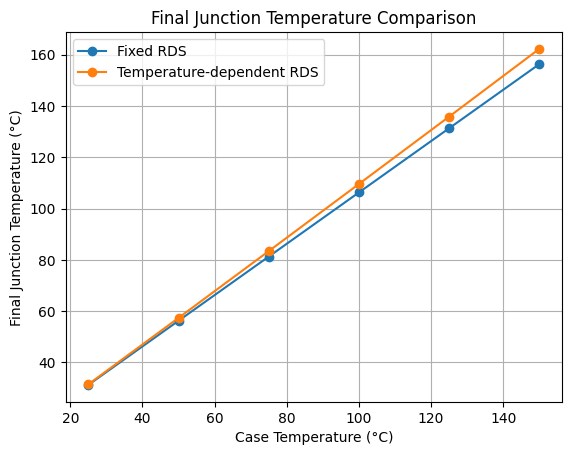

In [20]:
plt.plot(
    df_result["Tc (°C)"],
    df_result["Fixed RDS Tj (°C)"],
    marker="o",
    label="Fixed RDS"
)

plt.plot(
    df_result["Tc (°C)"],
    df_result["Tj (°C)"],
    marker="o",
    label="Temperature-dependent RDS"
)

plt.xlabel("Case Temperature (°C)")
plt.ylabel("Final Junction Temperature (°C)")
plt.title("Final Junction Temperature Comparison")
plt.grid()
plt.legend()
plt.show()

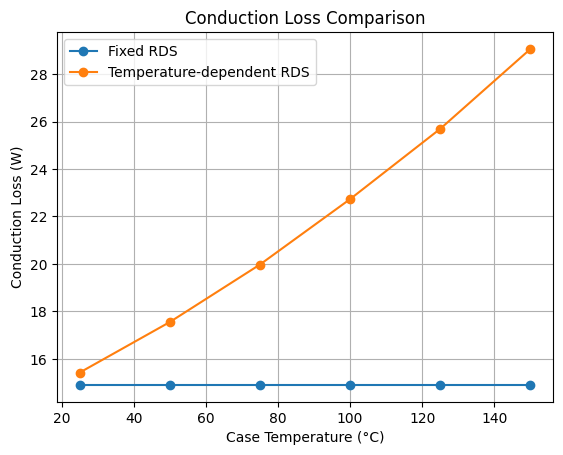

In [21]:
plt.plot(
    df_result["Tc (°C)"],
    df_result["Fixed RDS Loss (W)"],
    marker="o",
    label="Fixed RDS"
)

plt.plot(
    df_result["Tc (°C)"],
    df_result["Ploss (W)"],
    marker="o",
    label="Temperature-dependent RDS"
)

plt.xlabel("Case Temperature (°C)")
plt.ylabel("Conduction Loss (W)")
plt.title("Conduction Loss Comparison")
plt.grid()
plt.legend()
plt.show()

## Observation

- Case Temperature가 증가할수록 두 모델 모두 최종 Junction Temperature가 증가하였다.
- 25°C의 RDS(on)을 고정한 모델에서는 전도손실이 모든 Case Temperature 조건에서 14.9 W로 일정하였다.
- 반면 온도 의존 RDS(on)을 적용한 모델에서는 Junction Temperature가 상승함에 따라 RDS(on)이 증가하여 전도손실도 증가하였다.
- Tc = 25°C에서는 두 모델의 Junction Temperature 차이가 약 0.22°C로 작았으나, Tc = 150°C에서는 약 5.95°C까지 증가하였다.
- Tc = 150°C에서 온도 의존 모델의 전도손실은 약 29.06 W로, 고정 RDS 모델의 14.9 W보다 약 14.16 W 높게 나타났다.

## Interpretation

25°C에서의 RDS(on)을 모든 온도 조건에 동일하게 적용하면 고온에서 MOSFET의 전도손실을 과소평가할 수 있다.

실제 MOSFET에서는 Junction Temperature가 상승함에 따라 RDS(on)이 증가하고, 증가한 저항은 I²R 전도손실을 다시 증가시킨다. 따라서 전기적 손실과 열적 상태는 서로 독립적이지 않으며, 고온 조건의 Junction Temperature를 예측할 때는 온도 의존 RDS(on)을 고려할 필요가 있다.

본 분석에서는 Case Temperature를 각 조건에서 일정하게 유지하는 정상상태 모델을 사용하였으며, 시간에 따른 온도 변화는 포함하지 않았다.


In [27]:
df_sensing=df_result.copy()
df_sensing  

,Tc (°C),Tj (°C),Rds (mΩ),Ploss (W),Fixed RDS Tj (°C),Fixed RDS Loss (W),Tj Difference (°C),Loss Difference (W)
0,25,31.475571,1.541803,15.418027,31.258,14.9,0.217571,0.518027
1,50,57.370397,1.754856,17.548563,56.258,14.9,1.112397,2.648563
2,75,83.388375,1.997232,19.972321,81.258,14.9,2.130375,5.072321
3,100,109.547014,2.273099,22.730986,106.258,14.9,3.289014,7.830986
4,125,135.791909,2.569502,25.695021,131.258,14.9,4.533909,10.795021
5,150,162.205151,2.905988,29.059884,156.258,14.9,5.947151,14.159884


In [ ]:
df_sensing["I_true (A)"] = I


100

In [29]:
df_sensing["VDS (V)"] = (
    df_sensing["I_true (A)"]
    * df_sensing["Rds (mΩ)"]
    * 0.001
)

df_sensing

,Tc (°C),Tj (°C),Rds (mΩ),Ploss (W),Fixed RDS Tj (°C),Fixed RDS Loss (W),Tj Difference (°C),Loss Difference (W),I_true (A),VDS (V)
0,25,31.475571,1.541803,15.418027,31.258,14.9,0.217571,0.518027,100,0.154180
1,50,57.370397,1.754856,17.548563,56.258,14.9,1.112397,2.648563,100,0.175486
2,75,83.388375,1.997232,19.972321,81.258,14.9,2.130375,5.072321,100,0.199723
3,100,109.547014,2.273099,22.730986,106.258,14.9,3.289014,7.830986,100,0.227310
4,125,135.791909,2.569502,25.695021,131.258,14.9,4.533909,10.795021,100,0.256950
5,150,162.205151,2.905988,29.059884,156.258,14.9,5.947151,14.159884,100,0.290599


In [30]:
# 고정 저항 전류 추정
rds_ref_ohm = 1.49 * 0.001

df_sensing["I_fixed (A)"] = (
    df_sensing["VDS (V)"] / rds_ref_ohm
)

df_sensing

,Tc (°C),Tj (°C),Rds (mΩ),Ploss (W),Fixed RDS Tj (°C),Fixed RDS Loss (W),Tj Difference (°C),Loss Difference (W),I_true (A),VDS (V),I_fixed (A)
0,25,31.475571,1.541803,15.418027,31.258,14.9,0.217571,0.518027,100,0.154180,103.476689
1,50,57.370397,1.754856,17.548563,56.258,14.9,1.112397,2.648563,100,0.175486,117.775593
2,75,83.388375,1.997232,19.972321,81.258,14.9,2.130375,5.072321,100,0.199723,134.042426
3,100,109.547014,2.273099,22.730986,106.258,14.9,3.289014,7.830986,100,0.227310,152.556951
4,125,135.791909,2.569502,25.695021,131.258,14.9,4.533909,10.795021,100,0.256950,172.449806
5,150,162.205151,2.905988,29.059884,156.258,14.9,5.947151,14.159884,100,0.290599,195.032778


In [31]:
df_sensing["Error (A)"] = (
    df_sensing["I_fixed (A)"] - df_sensing["I_true (A)"]
)

df_sensing["Error (%)"] = (
    df_sensing["Error (A)"] / df_sensing["I_true (A)"] * 100
)

df_sensing

,Tc (°C),Tj (°C),Rds (mΩ),Ploss (W),Fixed RDS Tj (°C),Fixed RDS Loss (W),Tj Difference (°C),Loss Difference (W),I_true (A),VDS (V),I_fixed (A),Error (A),Error (%)
0,25,31.475571,1.541803,15.418027,31.258,14.9,0.217571,0.518027,100,0.154180,103.476689,3.476689,3.476689
1,50,57.370397,1.754856,17.548563,56.258,14.9,1.112397,2.648563,100,0.175486,117.775593,17.775593,17.775593
2,75,83.388375,1.997232,19.972321,81.258,14.9,2.130375,5.072321,100,0.199723,134.042426,34.042426,34.042426
3,100,109.547014,2.273099,22.730986,106.258,14.9,3.289014,7.830986,100,0.227310,152.556951,52.556951,52.556951
4,125,135.791909,2.569502,25.695021,131.258,14.9,4.533909,10.795021,100,0.256950,172.449806,72.449806,72.449806
5,150,162.205151,2.905988,29.059884,156.258,14.9,5.947151,14.159884,100,0.290599,195.032778,95.032778,95.032778


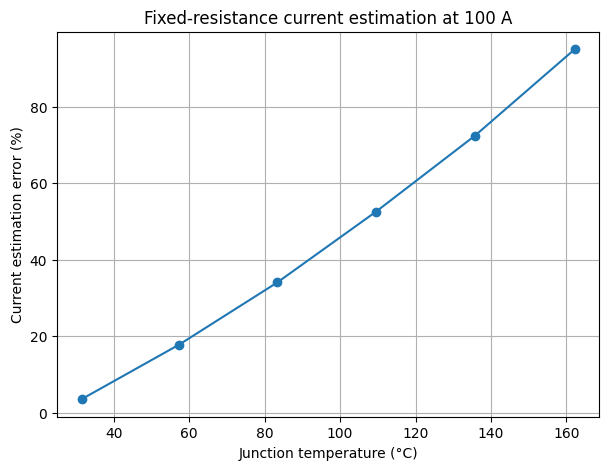

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(
    df_sensing["Tj (°C)"],
    df_sensing["Error (%)"],
    marker="o"
)

plt.xlabel("Junction temperature (°C)")
plt.ylabel("Current estimation error (%)")
plt.title("Fixed-resistance current estimation at 100 A")
plt.grid(True)

plt.show()

온도 상승에 따라 고정 저항 방식의 전류 추정 오차가 최대 약 95%까지 증가했다. 따라서 본 시험 조건에서는 정확한 전류 추정을 위해 온도에 따른 RDS(on) 변화를 반영하는 보상이 필요하다.

In [43]:
# 전류·케이스 온도별 자기발열 및 전류 추정 오차 분석

# 여러 전류와 케이스 온도 조건에서 
# 자기발열에 따른 접합온도와 저항, 
# VDS를 계산하고, 
# 고정 저항으로 전류를 추정했을 때 오차 비교
current_list = [25, 50, 75, 100]
results = []
for I_true in current_list:
    for Tc in Tc_l:
        Tj = Tc

        for r in range(max_iter):
            Rds_mohm = np.interp(
                Tj,
                df_t["Tj (°C)"],
                df_t["RDS(on) (mΩ)"]
            )

            Rds = Rds_mohm / 1000
            P_loss = I_true**2 * Rds
            Tj_new = Tc + P_loss * Rth_JC

            if abs(Tj_new - Tj) < tolerance:
                Tj = Tj_new
                break

            Tj = Tj_new
        Rds_mohm = np.interp(
            Tj,
            df_t["Tj (°C)"],
            df_t["RDS(on) (mΩ)"]
        )

        Rds = Rds_mohm / 1000
        P_loss = I_true**2 * Rds
        VDS = I_true * Rds
        Rds_fixed = 1.49 / 1000

        I_fixed = VDS / Rds_fixed

        error_A = I_fixed - I_true
        error_percent = error_A / I_true * 100
        results.append({
            "I_true (A)": I_true,
            "Tc (°C)": Tc,
            "Tj (°C)": Tj,
            "Rds (mΩ)": Rds_mohm,
            "Ploss (W)": P_loss,
            "VDS (V)": VDS,
            "I_fixed (A)": I_fixed,
            "Error (A)": error_A,
            "Error (%)": error_percent
        })
df_multi = pd.DataFrame(results)

df_multi

,I_true (A),Tc (°C),Tj (°C),Rds (mΩ),Ploss (W),VDS (V),I_fixed (A),Error (A),Error (%)
0,25,25,25.391946,1.493136,0.933210,0.037328,25.052610,0.052610,0.210441
1,25,50,50.444652,1.693913,1.058696,0.042348,28.421358,3.421358,13.685432
2,25,75,75.502747,1.915229,1.197018,0.047881,32.134708,7.134708,28.538830
3,25,100,100.571244,2.176169,1.360106,0.054404,36.512910,11.512910,46.051640
4,25,125,125.642524,2.447710,1.529819,0.061193,41.068965,16.068965,64.275858
5,25,150,150.721827,2.749817,1.718636,0.068745,46.137867,21.137867,84.551466
6,50,25,26.577752,1.502622,3.756555,0.075131,50.423558,0.423558,0.847115
7,50,50,51.791048,1.705761,4.264403,0.085288,57.240309,7.240309,14.480619
8,50,75,77.027639,1.931087,4.827719,0.096554,64.801592,14.801592,29.603184
9,50,100,102.304631,2.194890,5.487225,0.109745,73.654027,23.654027,47.308055


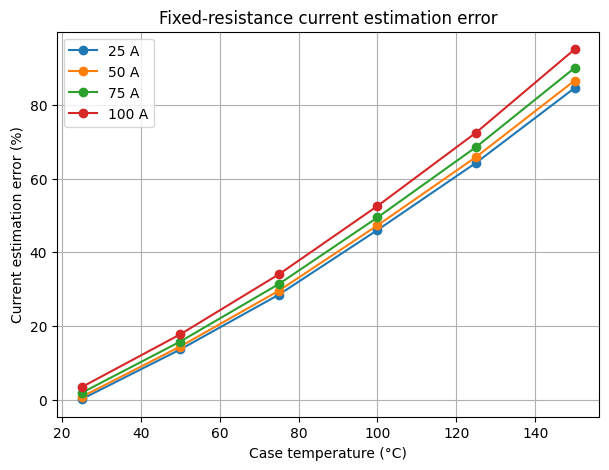

In [44]:
plt.figure(figsize=(7, 5))

for I_true in current_list:
    selected = df_multi[df_multi["I_true (A)"] == I_true]

    plt.plot(
        selected["Tc (°C)"],
        selected["Error (%)"],
        marker="o",
        label=f"{I_true} A"
    )

plt.xlabel("Case temperature (°C)")
plt.ylabel("Current estimation error (%)")
plt.title("Fixed-resistance current estimation error")
plt.legend()
plt.grid(True)
plt.show()

### 결과 해석

시험 범위에서 케이스 온도가 높을수록 고정 저항 방식의 전류 추정 오차가 증가했다. 같은 케이스 온도에서도 전류가 커지면 자기발열로 접합온도와 RDS(on)이 상승하여 오차가 더 커졌다.

최대 오차는 기준 전류 100 A, 케이스 온도 150°C 조건에서 약 95.03%로 나타났다. 이는 온도에 따라 증가한 저항을 반영하지 않고 25°C 기준 저항으로 전류를 환산하여 발생한 과대 추정이다.

따라서 본 모델과 시험 범위에서는 정확한 전류 추정을 위해 온도에 따른 저항 변화를 보상할 필요가 있다.